<a href="https://colab.research.google.com/github/Fuege/ISYS2001-YoussefAli/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fuege/ISYS2001-YoussefAli/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb)


# Lab Ticket: Charting Real Stock Data

This week you used the Gemini API: you sent it text, and it sent text back. A stock service works the same way. You send a request (which company, what kind of data) and it sends back a structured response you can turn into a chart.

Your job is to fetch real stock data and draw one clear figure from it. The fetching is written for you. The figure is yours.

## The brief

**API to integrate:** Alpha Vantage (free).

Get your own key the same way you got your Gemini key:

1. Sign up at https://www.alphavantage.co/support/#api-key
2. Store it in Colab Secrets as `ALPHAVANTAGE_API_KEY`, with Notebook access switched on.

Use your own key, not the shared `demo` key. The demo key only ever returns data for IBM.

**Figure I expect:** a line chart of the daily closing price for one ticker of your choice, across the window the data covers. Label both axes, and give the chart a title that names the ticker.

**A note on limits:** the free key allows only about 25 requests a day. Run the fetch cell once. After that the data lives in a DataFrame called `prices`, so do all your charting from that. Re-running the fetch cell over and over will use up your daily quota, and you will start getting a notice instead of data.

In [3]:
from google.colab import userdata
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")


def get_stock_data(ticker):
    """Fetch daily prices for a ticker, sorted from oldest to newest."""
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": ticker,
        "apikey": API_KEY,
        "outputsize": "compact",  # most recent 100 trading days
    }

    try:
        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()
    except requests.RequestException:
        # Request errors can include the URL and API key. Do not print them.
        raise RuntimeError("Stock request failed. Check your connection and API key.") from None
    data = response.json()

    if "Time Series (Daily)" not in data:
        reason = (data.get("Error Message")
                  or data.get("Note")
                  or data.get("Information")
                  or data)
        raise ValueError(f"No price data returned. Alpha Vantage said: {reason}")

    prices = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
    })
    prices = prices.astype(float)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices


In [4]:
# Run this once after adding ALPHAVANTAGE_API_KEY to Colab Secrets.
TICKER = "AAPL"
prices = get_stock_data(TICKER)
prices.tail()


,Open,High,Low,Close,Volume
2026-09-23,341.075,341.800,335.50,337.02,31658823.0
2026-09-24,336.720,338.910,334.30,335.92,24733098.0
2026-09-25,336.040,341.670,334.53,341.07,30002507.0
2026-09-28,340.370,342.988,338.04,338.40,32820848.0
2026-09-29,336.965,337.085,328.70,329.40,37681009.0


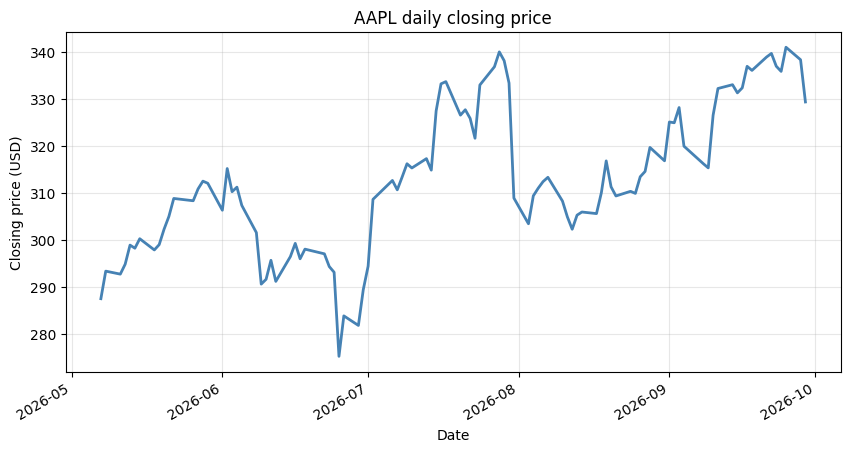

In [5]:
# Chart the closing price using the DataFrame already fetched above.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(prices.index, prices["Close"], color="steelblue", linewidth=2)
ax.set_title(f"{TICKER} daily closing price")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (USD)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.show()


## Before you finish

- The fetch returns a DataFrame of daily open, high, low, close, and volume values. One row represents one trading day for the selected ticker.
- A line chart suits closing prices because the dates are ordered and the goal is to see how the price changed over time.
- The chart shows AAPL's daily closing price in US dollars across the dates returned by the API. A price chart alone does not say whether to buy or sell.


